# Phase 3 statistical analysis: Defense A on the frozen eval set

Brings forward the Phase 3 analysis on existing Defense A data: per-defense metrics with bootstrap 95% CIs, per-subcategory recall, threshold sweeps, paired McNemar DeBERTa vs Prompt Guard 2, and the small Defense B sneak-preview / judge-sensitivity slice. No API calls. Defense B at scale and BIPIA are deferred until Groq quota is back.

Inputs:
- `results/defense_a_full_eval_set.csv` (4,546 rows, both classifiers)
- `results/defense_b_sneak_preview.csv`, `results/defense_b_neuralchemy_jailbreak_preview.csv`, `results/defense_b_neuralchemy_encoding_preview.csv`
- `results/defense_b_judge_sensitivity_deepset.csv`

Outputs:
- `results/defense_a_full_metrics.csv` per-scope metrics + bootstrap CIs
- `results/defense_a_full_subcategory_recall.csv` neuralchemy subcategory breakdown both classifiers
- `results/defense_a_mcnemar.csv` paired DeBERTa vs PG2 contingency + p-value
- `results/figures/analysis_threshold_sweep_grid.png` 3 datasets x 2 classifiers
- `results/figures/analysis_subcategory_recall_compare.png` DeBERTa vs PG2 per subcategory

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / '.git').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.metrics import headline_metrics, bootstrap_ci, kappa, mcnemar
from src.utils import set_seed

set_seed(42)
RES = REPO_ROOT / 'results'
FIG = RES / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 80)

In [2]:
df = pd.read_csv(RES / 'defense_a_full_eval_set.csv')
print(f'rows: {len(df)}')
print(df.groupby(['dataset', 'label']).size().to_string())

rows: 4546
dataset      label
deepset      0         343
             1         203
neuralchemy  0         793
             1        1207
spml         0        1000
             1        1000


## 1. Per-defense headline metrics with bootstrap CIs

Per dataset and overall, for both classifiers at default threshold.

In [3]:
rows = []
scopes = [('overall', df)] + [(ds, df[df['dataset'] == ds]) for ds in ['deepset', 'neuralchemy', 'spml']]
for classifier in ['deberta', 'pg2']:
    pred_col = f'{classifier}_pred_label_id'
    score_col = f'{classifier}_injection_score'
    for scope_name, scope in scopes:
        if len(scope) == 0:
            continue
        y = scope['label'].values
        yp = scope[pred_col].values
        ys = scope[score_col].values
        m = headline_metrics(y, yp, ys)
        ci = bootstrap_ci(y, yp, ys, n_iter=1000, seed=42)
        row = {'classifier': classifier, 'scope': scope_name, 'n': len(scope), **m}
        for k, (lo, hi) in ci.items():
            row[f'{k}_lo'] = round(lo, 4)
            row[f'{k}_hi'] = round(hi, 4)
        rows.append(row)

metrics_df = pd.DataFrame(rows)
for c in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
    if c in metrics_df.columns:
        metrics_df[c] = metrics_df[c].round(4)
metrics_df.to_csv(RES / 'defense_a_full_metrics.csv', index=False)
metrics_df

,classifier,scope,n,accuracy,precision,recall,f1,auc,accuracy_lo,accuracy_hi,precision_lo,precision_hi,recall_lo,recall_hi,f1_lo,f1_hi,auc_lo,auc_hi
0,deberta,overall,4546,0.9089,0.9495,0.8747,0.9106,0.9655,0.8999,0.9171,0.9399,0.9581,0.8609,0.8876,0.9015,0.9187,0.9602,0.9703
1,deberta,deepset,546,0.7802,0.9560,0.4286,0.5918,0.8812,0.7454,0.8132,0.9100,0.9898,0.3622,0.5000,0.5239,0.6565,0.8460,0.9148
2,deberta,neuralchemy,2000,0.9015,0.9846,0.8500,0.9124,0.9700,0.8880,0.9140,0.9762,0.9914,0.8284,0.8702,0.8994,0.9244,0.9622,0.9774
3,deberta,spml,2000,0.9515,0.9154,0.9950,0.9535,0.9978,0.9415,0.9610,0.8982,0.9322,0.9901,0.9990,0.9439,0.9632,0.9959,0.9991
4,pg2,overall,4546,0.7323,0.9838,0.5033,0.6659,0.9334,0.7197,0.7451,0.9762,0.9904,0.4859,0.5226,0.6500,0.6829,0.9265,0.9401
5,pg2,deepset,546,0.7234,0.9815,0.2611,0.4125,0.9483,0.6832,0.7619,0.9375,1.0000,0.2009,0.3223,0.3333,0.4842,0.9294,0.9641
6,pg2,neuralchemy,2000,0.7010,0.9706,0.5203,0.6775,0.8536,0.6805,0.7195,0.9565,0.9827,0.4914,0.5474,0.6514,0.7003,0.8362,0.8679
7,pg2,spml,2000,0.7660,1.0000,0.5320,0.6945,0.9953,0.7475,0.7835,1.0000,1.0000,0.5000,0.5615,0.6667,0.7192,0.9934,0.9969


## 2. Per-classifier comparison: pretty table for the report

In [4]:
def fmt(v, lo, hi):
    return f'{v:.3f} [{lo:.3f}, {hi:.3f}]'

rows = []
for _, r in metrics_df.iterrows():
    rows.append({
        'classifier': r['classifier'],
        'scope': r['scope'],
        'n': int(r['n']),
        'accuracy [95% CI]':  fmt(r['accuracy'],  r['accuracy_lo'],  r['accuracy_hi']),
        'precision [95% CI]': fmt(r['precision'], r['precision_lo'], r['precision_hi']),
        'recall [95% CI]':    fmt(r['recall'],    r['recall_lo'],    r['recall_hi']),
        'f1 [95% CI]':        fmt(r['f1'],        r['f1_lo'],        r['f1_hi']),
        'auc [95% CI]':       fmt(r['auc'],       r['auc_lo'],       r['auc_hi']) if 'auc' in r and not pd.isna(r['auc']) else '',
    })
pretty = pd.DataFrame(rows)
pretty.to_csv(RES / 'defense_a_full_metrics_pretty.csv', index=False)
pretty

,classifier,scope,n,accuracy [95% CI],precision [95% CI],recall [95% CI],f1 [95% CI],auc [95% CI]
0,deberta,overall,4546,"0.909 [0.900, 0.917]","0.950 [0.940, 0.958]","0.875 [0.861, 0.888]","0.911 [0.901, 0.919]","0.966 [0.960, 0.970]"
1,deberta,deepset,546,"0.780 [0.745, 0.813]","0.956 [0.910, 0.990]","0.429 [0.362, 0.500]","0.592 [0.524, 0.656]","0.881 [0.846, 0.915]"
2,deberta,neuralchemy,2000,"0.901 [0.888, 0.914]","0.985 [0.976, 0.991]","0.850 [0.828, 0.870]","0.912 [0.899, 0.924]","0.970 [0.962, 0.977]"
3,deberta,spml,2000,"0.952 [0.942, 0.961]","0.915 [0.898, 0.932]","0.995 [0.990, 0.999]","0.954 [0.944, 0.963]","0.998 [0.996, 0.999]"
4,pg2,overall,4546,"0.732 [0.720, 0.745]","0.984 [0.976, 0.990]","0.503 [0.486, 0.523]","0.666 [0.650, 0.683]","0.933 [0.926, 0.940]"
5,pg2,deepset,546,"0.723 [0.683, 0.762]","0.982 [0.938, 1.000]","0.261 [0.201, 0.322]","0.412 [0.333, 0.484]","0.948 [0.929, 0.964]"
6,pg2,neuralchemy,2000,"0.701 [0.680, 0.720]","0.971 [0.957, 0.983]","0.520 [0.491, 0.547]","0.677 [0.651, 0.700]","0.854 [0.836, 0.868]"
7,pg2,spml,2000,"0.766 [0.748, 0.783]","1.000 [1.000, 1.000]","0.532 [0.500, 0.561]","0.695 [0.667, 0.719]","0.995 [0.993, 0.997]"


## 3. Paired McNemar's test: DeBERTa vs Prompt Guard 2

Same prompts to both classifiers, same threshold, paired binary outcomes. Tests whether the two classifiers' error patterns are systematically different.

In [5]:
rows = []
for scope_name, scope in scopes:
    y = scope['label'].values
    deberta_pred = scope['deberta_pred_label_id'].values
    pg2_pred = scope['pg2_pred_label_id'].values
    res = mcnemar(y, deberta_pred, pg2_pred, exact=False)
    rows.append({'scope': scope_name, 'n': len(scope), **res})
mcnemar_df = pd.DataFrame(rows)
mcnemar_df.to_csv(RES / 'defense_a_mcnemar.csv', index=False)
print('McNemar paired comparison: DeBERTa correct/PG2 wrong vs DeBERTa wrong/PG2 correct')
mcnemar_df

McNemar paired comparison: DeBERTa correct/PG2 wrong vs DeBERTa wrong/PG2 correct


,scope,n,b,c,chi2,p_value,test
0,overall,4546,931,128,607.369216,0.000000,chi2_continuity_corrected
1,deepset,546,44,13,15.789474,0.000071,chi2_continuity_corrected
2,neuralchemy,2000,423,22,359.550562,0.000000,chi2_continuity_corrected
3,spml,2000,464,93,245.780969,0.000000,chi2_continuity_corrected


## 4. Per-subcategory recall on neuralchemy, both classifiers

Injection rows only. Recall is the fraction of true injections each classifier catches in that subcategory.

In [6]:
nc = df[(df['dataset'] == 'neuralchemy') & (df['label'] == 1)].copy()
nc['deberta_caught'] = (nc['deberta_pred_label_id'] == 1).astype(int)
nc['pg2_caught']     = (nc['pg2_pred_label_id']     == 1).astype(int)

by_cat = nc.groupby('subcategory').agg(
    n=('deberta_caught', 'size'),
    deberta_recall=('deberta_caught', 'mean'),
    pg2_recall=('pg2_caught', 'mean'),
).reset_index().sort_values('n', ascending=False)
by_cat['deberta_recall'] = by_cat['deberta_recall'].round(3)
by_cat['pg2_recall'] = by_cat['pg2_recall'].round(3)
by_cat['delta'] = (by_cat['deberta_recall'] - by_cat['pg2_recall']).round(3)
by_cat.to_csv(RES / 'defense_a_full_subcategory_recall.csv', index=False)
by_cat

,subcategory,n,deberta_recall,pg2_recall,delta
7,direct_injection,637,0.981,0.743,0.238
0,adversarial,174,0.718,0.069,0.649
12,jailbreak,133,0.519,0.489,0.030
8,encoding,81,0.667,0.062,0.605
28,training_extraction,31,0.935,0.129,0.806
25,system_manipulation,13,0.923,0.538,0.385
27,token_smuggling,12,1.000,0.750,0.250
22,rag_poisoning,12,1.000,0.750,0.250
18,persona_replacement,11,0.818,0.455,0.363
1,agent_manipulation,11,0.636,0.273,0.363


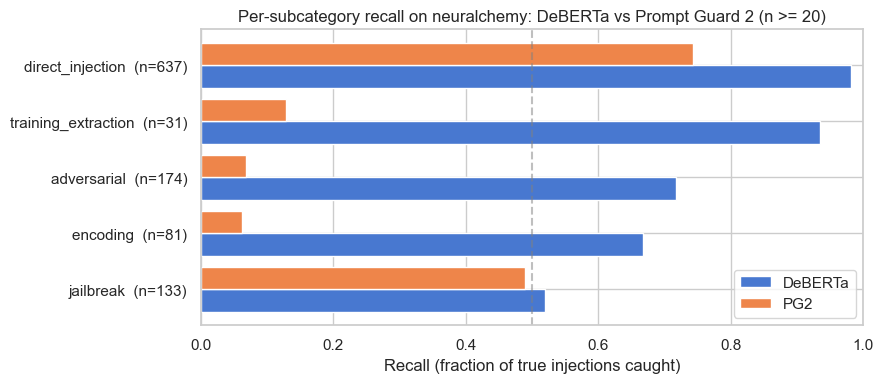

In [7]:
# Visualize: side-by-side recall by subcategory, sorted by DeBERTa recall
top = by_cat[by_cat['n'] >= 20].sort_values('deberta_recall').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, max(4, len(top) * 0.35)))
y = np.arange(len(top))
width = 0.4
ax.barh(y - width/2, top['deberta_recall'], height=width, label='DeBERTa', color='#4878D0')
ax.barh(y + width/2, top['pg2_recall'],     height=width, label='PG2',     color='#EE854A')
ax.set_yticks(y)
ax.set_yticklabels(top['subcategory'] + '  (n=' + top['n'].astype(str) + ')')
ax.set_xlim(0, 1)
ax.set_xlabel('Recall (fraction of true injections caught)')
ax.axvline(0.5, ls='--', color='gray', alpha=0.5)
ax.set_title('Per-subcategory recall on neuralchemy: DeBERTa vs Prompt Guard 2 (n >= 20)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG / 'analysis_subcategory_recall_compare.png', dpi=150)
plt.show()

## 5. Threshold sweep across datasets and classifiers

3-row by 2-column grid: rows = datasets (deepset/neuralchemy/spml), cols = classifiers (DeBERTa/PG2). Each cell plots F1, precision, recall vs decision threshold.

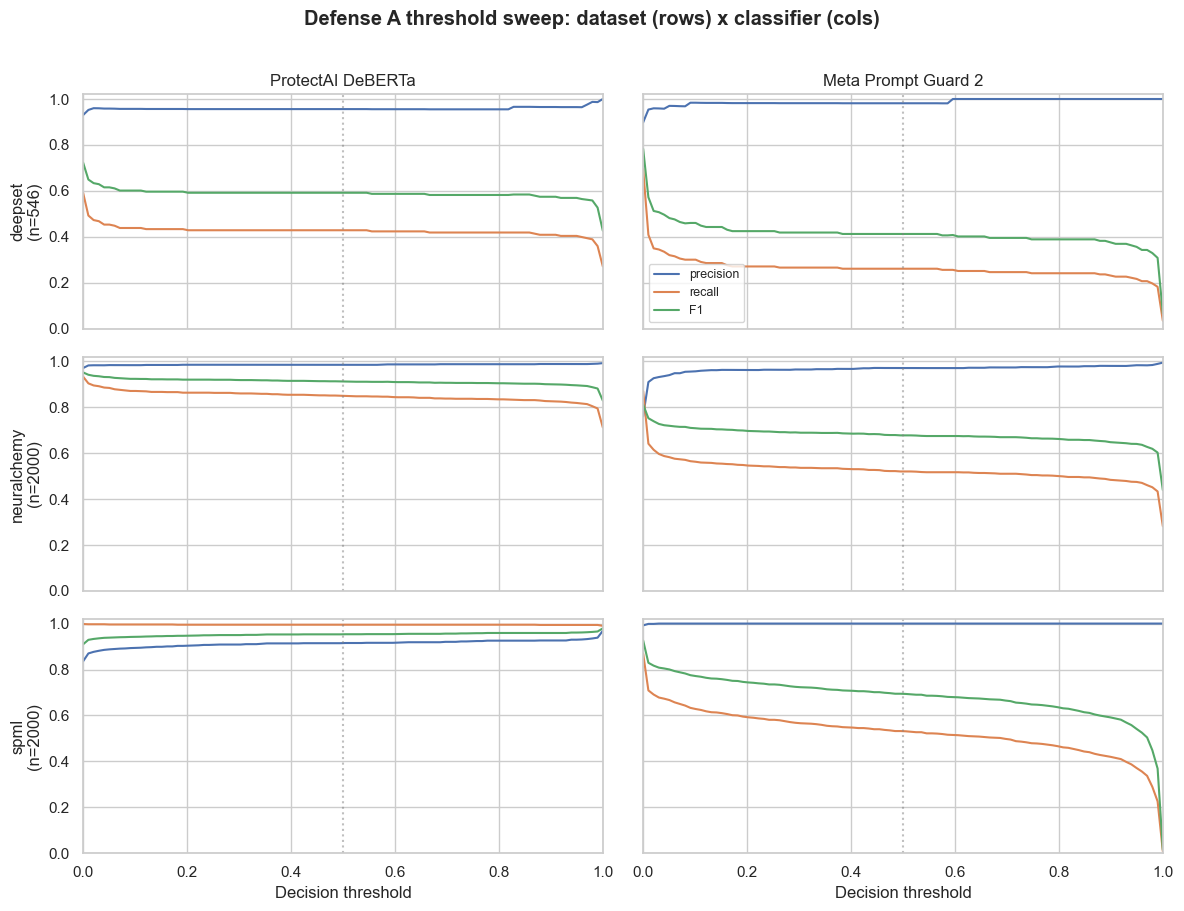

In [8]:
thresholds = np.linspace(0.001, 0.999, 100)
datasets = ['deepset', 'neuralchemy', 'spml']
classifiers = ['deberta', 'pg2']

fig, axes = plt.subplots(len(datasets), len(classifiers), figsize=(12, 9), sharex=True, sharey=True)
for i, ds in enumerate(datasets):
    sub = df[df['dataset'] == ds]
    y = sub['label'].values
    for j, cls in enumerate(classifiers):
        ax = axes[i, j]
        ys = sub[f'{cls}_injection_score'].values
        prec_t, rec_t, f1_t = [], [], []
        for t in thresholds:
            yp = (ys >= t).astype(int)
            p, r, f, _ = precision_recall_fscore_support(y, yp, average='binary', pos_label=1, zero_division=0)
            prec_t.append(p); rec_t.append(r); f1_t.append(f)
        ax.plot(thresholds, prec_t, lw=1.5, label='precision')
        ax.plot(thresholds, rec_t,  lw=1.5, label='recall')
        ax.plot(thresholds, f1_t,   lw=1.5, label='F1')
        ax.axvline(0.5, ls=':', color='gray', alpha=0.5)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
        if i == 0:
            ax.set_title({'deberta': 'ProtectAI DeBERTa', 'pg2': 'Meta Prompt Guard 2'}[cls])
        if j == 0:
            ax.set_ylabel(f'{ds}\n(n={len(sub)})')
        if i == len(datasets) - 1:
            ax.set_xlabel('Decision threshold')
        if i == 0 and j == len(classifiers) - 1:
            ax.legend(loc='lower left', fontsize=9)

fig.suptitle('Defense A threshold sweep: dataset (rows) x classifier (cols)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG / 'analysis_threshold_sweep_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Defense B sneak-preview slice (24 cases across 3 attack classes)

Limited n. Reports per-attack-class hijack rates from the existing sneak previews. Will be superseded by the 500-row pilot once Groq quota resumes.

In [9]:
previews = {
    'deepset role-play': RES / 'defense_b_sneak_preview.csv',
    'neuralchemy jailbreak': RES / 'defense_b_neuralchemy_jailbreak_preview.csv',
    'neuralchemy encoding': RES / 'defense_b_neuralchemy_encoding_preview.csv',
}
rows = []
for name, path in previews.items():
    if not path.exists():
        continue
    d = pd.read_csv(path)
    n = len(d)
    hij = int((d['judge_hijacked'] == True).sum())
    rows.append({'attack_class': name, 'n': n, 'judge_hijacked': hij, 'rate': round(hij / n, 3) if n else None})
sneak_summary = pd.DataFrame(rows)
sneak_summary

,attack_class,n,judge_hijacked,rate
0,deepset role-play,8,4,0.500
1,neuralchemy jailbreak,8,0,0.000
2,neuralchemy encoding,8,1,0.125


## 7. Judge sensitivity: Claude Sonnet 4.6 vs GPT-4o on the deepset 8

Cohen's kappa is not meaningful at n=8 but the agreement rate is informative.

In [10]:
sens_path = RES / 'defense_b_judge_sensitivity_deepset.csv'
if sens_path.exists():
    sens = pd.read_csv(sens_path)
    print(f'rows: {len(sens)}')
    claude = sens['claude_hijacked'].astype(int)
    gpt    = sens['gpt4o_hijacked'].astype(int)
    print(f'Claude flagged: {claude.sum()}/{len(claude)}')
    print(f'GPT-4o flagged: {gpt.sum()}/{len(gpt)}')
    print(f'Agreement rate: {(claude == gpt).mean():.3f}')
    print(f"Cohen's kappa  (note: n=8 is below the threshold where kappa is meaningful): {kappa(claude, gpt):.3f}")
else:
    print('sensitivity CSV not found; run scripts/run_gpt4o_sensitivity_deepset.py first')

rows: 8
Claude flagged: 4/8
GPT-4o flagged: 2/8
Agreement rate: 0.750
Cohen's kappa  (note: n=8 is below the threshold where kappa is meaningful): 0.500


## 8. Summary for the final report

Sentences and numbers that are stable enough to drop into Section 5 (Results) of the final report. Update when the 500-row pilot completes.

In [11]:
overall_deberta = metrics_df[(metrics_df['classifier'] == 'deberta') & (metrics_df['scope'] == 'overall')].iloc[0]
overall_pg2     = metrics_df[(metrics_df['classifier'] == 'pg2')     & (metrics_df['scope'] == 'overall')].iloc[0]

summary_lines = [
    '## Defense A on frozen eval set (n=4,546)',
    '',
    f"ProtectAI DeBERTa v3 v2: F1 {overall_deberta['f1']} [{overall_deberta['f1_lo']}, {overall_deberta['f1_hi']}], "
    f"AUC {overall_deberta['auc']} [{overall_deberta['auc_lo']}, {overall_deberta['auc_hi']}]",
    '',
    f"Meta Prompt Guard 2 86M:    F1 {overall_pg2['f1']} [{overall_pg2['f1_lo']}, {overall_pg2['f1_hi']}], "
    f"AUC {overall_pg2['auc']} [{overall_pg2['auc_lo']}, {overall_pg2['auc_hi']}]",
    '',
    '## Paired McNemar (DeBERTa vs PG2)',
]
for _, r in mcnemar_df.iterrows():
    summary_lines.append(f"- {r['scope']} (n={r['n']}): b={r['b']}, c={r['c']}, p={r['p_value']:.4g}")
summary_lines.append('')
summary_lines.append('## Per-subcategory blind spots (neuralchemy, n>=20)')
for _, r in by_cat[by_cat['n'] >= 20].sort_values('deberta_recall').head(5).iterrows():
    summary_lines.append(f"- {r['subcategory']} (n={r['n']}): DeBERTa {r['deberta_recall']}, PG2 {r['pg2_recall']}")
print('\n'.join(summary_lines))

## Defense A on frozen eval set (n=4,546)

ProtectAI DeBERTa v3 v2: F1 0.9106 [0.9015, 0.9187], AUC 0.9655 [0.9602, 0.9703]

Meta Prompt Guard 2 86M:    F1 0.6659 [0.65, 0.6829], AUC 0.9334 [0.9265, 0.9401]

## Paired McNemar (DeBERTa vs PG2)
- overall (n=4546): b=931, c=128, p=0
- deepset (n=546): b=44, c=13, p=7.08e-05
- neuralchemy (n=2000): b=423, c=22, p=0
- spml (n=2000): b=464, c=93, p=0

## Per-subcategory blind spots (neuralchemy, n>=20)
- jailbreak (n=133): DeBERTa 0.519, PG2 0.489
- encoding (n=81): DeBERTa 0.667, PG2 0.062
- adversarial (n=174): DeBERTa 0.718, PG2 0.069
- training_extraction (n=31): DeBERTa 0.935, PG2 0.129
- direct_injection (n=637): DeBERTa 0.981, PG2 0.743


## Outputs written

- `results/defense_a_full_metrics.csv` (per-scope x per-classifier headline metrics + CIs)
- `results/defense_a_full_metrics_pretty.csv` (same data, report-ready strings)
- `results/defense_a_full_subcategory_recall.csv` (per-subcategory recall comparison)
- `results/defense_a_mcnemar.csv` (paired test results per scope)
- `results/figures/analysis_threshold_sweep_grid.png` (3 datasets x 2 classifiers)
- `results/figures/analysis_subcategory_recall_compare.png` (DeBERTa vs PG2 per subcategory)